# Setup Notebook (Virtual machine)

In this section all required packages will be installed.

In [17]:
!apt-get update
!apt-get install -y swig python3-numpy python3-dev cmake zlib1g-dev libjpeg-dev xvfb ffmpeg xorg-dev python3-opengl libboost-all-dev libsdl2-dev
!pip install gymnasium==1.2.3 gymnasium[box2d] pyvirtualdisplay imageio-ffmpeg moviepy==1.0.3
!pip install onnx onnx2pytorch==0.4.1
!pip install opencv-python pyvirtualdisplay

!wget https://raw.githubusercontent.com/StefOe/colab-pytorch-utils/master/utils.py
import utils


!pip install minigrid==3.0.0

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:4 https://cli.github.com/packages stable InRelease
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [18]:
import time
from datetime import datetime
import numpy as np
from collections import deque, namedtuple
import collections
import os
import time
import shutil
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import cv2
import gymnasium as gym
import gymnasium.spaces

import matplotlib.pyplot as plt
import copy
%matplotlib inline
!nvcc --version

from matplotlib import animation
import seaborn as sns; sns.set()
from IPython.display import clear_output, HTML
from IPython import display

import torch.onnx

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


# Mount your drive and use GPU

Here you can mount your GDrive folders (where you will store checkpoints during training).

In [19]:
if not os.path.exists('/content/gdrive'):
    from google.colab import drive
    drive.mount('/content/gdrive')

In [20]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


# Replay Buffer

The replay buffer stores transitions - state, action, reward, next_state.

In [21]:
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])

class ReplayBuffer():
  def __init__(self, num_actions, memory_len = 10000):
      self.memory_len = memory_len
      self.transition = []
      self.num_actions = num_actions

  def add(self, state, action, reward, next_state, done):
      if self.length() > self.memory_len:
        self.remove()
      self.transition.append(Transition(state, action, reward, next_state, done))

  def sample_batch(self, batch_size = 32):
      minibatch = random.sample(self.transition, batch_size)
      states_mb, a_, reward_mb, next_states_mb, done_mb = map(np.array, zip(*minibatch))

      mb_reward = torch.from_numpy(reward_mb).to(device=device, dtype=torch.float32)
      mb_done = torch.from_numpy(done_mb.astype(int)).to(device=device)
      a_ = a_.astype(int)
      a_mb = np.zeros((a_.size, self.num_actions), dtype=np.float32)
      a_mb[np.arange(a_.size), a_] = 1
      mb_a = torch.from_numpy(a_mb).cuda().to(device=device)
      return states_mb, mb_a, mb_reward, next_states_mb, mb_done # states will be converted to tensors in forward pass

  def length(self):
      return len(self.transition)

  def remove(self):
      self.transition.pop(0)

# MINIGRID DQN-Training

This section contains the train function for the minigrid environment.

### Minigrid Environment and Policy Network





In [39]:
# Minigrid Environment
from minigrid.wrappers import ImgObsWrapper
class ChannelFirst(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        old_shape = env.observation_space.shape
        self.observation_space = {}
        self.observation_space = gym.spaces.Box(0, 255, shape=(3, 7, 7))

    def observation(self, observation):
        return np.swapaxes(observation, 2, 0)

class ScaledFloatFrame(gym.ObservationWrapper):
    def __init__(self, env):
        gym.ObservationWrapper.__init__(self, env)

    def observation(self, observation):
        # careful! This undoes the memory optimization, use
        # with smaller replay buffers only.
        return np.array(observation).astype(np.float32)

class MinigridEmpty5x5ImgObs(gym.Wrapper):
    """Minigrid with image observations provided by minigrid, partially observable."""
    def __init__(self, render=False):
        if render:
          env = gym.make('MiniGrid-Empty-5x5-v0', render_mode="rgb_array")
        else:
          env = gym.make('MiniGrid-Empty-5x5-v0')
        env = ScaledFloatFrame(ChannelFirst(ImgObsWrapper(env)))
        super().__init__(env)

class MinigridDoorKey6x6ImgObs(gym.Wrapper):
    """Minigrid with image observations provided by minigrid, partially observable."""
    def __init__(self, render=False):
        if render:
          env = gym.make('MiniGrid-DoorKey-6x6-v0', render_mode="rgb_array")
        else:
          env = gym.make('MiniGrid-DoorKey-6x6-v0')
        env = ScaledFloatFrame(ChannelFirst(ImgObsWrapper(env)))
        super().__init__(env)

In [40]:
env = MinigridDoorKey6x6ImgObs()
obs = env.reset()[0]
obs, obs.shape, env.action_space

(array([[[0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [2., 2., 2., 2., 2., 2., 0.],
         [2., 1., 5., 1., 1., 2., 0.],
         [2., 1., 1., 1., 1., 2., 0.]],
 
        [[0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [5., 5., 5., 5., 5., 5., 0.],
         [5., 0., 4., 0., 0., 5., 0.],
         [5., 0., 0., 0., 0., 5., 0.]],
 
        [[0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.]]], dtype=float32),
 (3, 7, 7),
 Discrete(7))

In [41]:
class MlpMinigridPolicy(nn.Module):
    def __init__(self, num_actions=7):
        super().__init__()
        self.num_actions = num_actions
        self.fc = nn.Sequential(nn.Flatten(),
                                nn.Linear(3*7**2, 256), nn.ReLU(),
                                nn.Linear(256, 256), nn.ReLU(),
                                nn.Linear(256, 64), nn.ReLU(),
                                nn.Linear(64, num_actions))
    def forward(self, x):
        if len(x.size()) == 3:
          x = x.unsqueeze(dim=0)
        x = x / 10.0
        return self.fc(x)

### Training utils

In [42]:
def plot(frame_idx, rewards, losses):
    clear_output(True)
    plt.figure(figsize=(20,5))
    plt.subplot(131)
    plt.title('frame %s. reward: %s' % (frame_idx, np.mean(rewards[-10:])))
    plt.plot(rewards)
    plt.subplot(132)
    plt.title('loss')
    plt.plot(losses)
    plt.show()

In [43]:
def set_seed(env, seed=None):
    if seed is not None:
        random.seed(seed)
        env.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)


In [60]:
num_episodes = 5000
buffer_size = 50000
epsilon = 1.0
timesteps = 0
minibatch_size = 64
gamma = 0.99
eval_episode = 100
num_eval = 10
tau = 1e-3
learning_rate = 0.0005
update_after = 500
epsilon_decay = 50000
epsilon_ub = 1.0
epsilon_lb = 0.1
train_every = 4
target_update_freq = 500
# set seed
np.random.seed(0)
torch.manual_seed(0)

In [61]:
print(device)

cuda


### Load model (if available)

In [62]:
# specify load path if available:

# load_path = '/content/gdrive/MyDrive/colab-drive/minigrid-model-2022_03_28-10_01_18.p'

load_path = '' # otherwise start with randomly initialized agent

# save the current model state
save_path = f"/content/gdrive/MyDrive/colab-drive/minigrid-model-{datetime.now().strftime('%Y_%m_%d-%H_%M_%S')}.p"
save_path = f"minigrid-model-{datetime.now().strftime('%Y_%m_%d-%H_%M_%S')}.p"

print(f'model checkpoints will be saved to: {save_path}')

def load_checkpoint(checkpoint_path='', device=device):
  dqn = MlpMinigridPolicy(num_actions=num_actions).to(device=device)
  dqn_target = MlpMinigridPolicy(num_actions=num_actions).to(device=device)
  timesteps = 0

  if checkpoint_path:
    print(f'Loading checkpoint {checkpoint_path}')
    checkpoint_dict = torch.load(checkpoint_path, map_location=device)
    model_params = checkpoint_dict['model_params']
    timesteps = checkpoint_dict['timesteps'] # environment steps

    dqn.load_state_dict(model_params) # makes a copy of model_params
    dqn_target.load_state_dict(model_params)
  else:
    print(f'Starting training from scratch.')

  return dqn, dqn_target, timesteps

def store_checkpoint(checkpoint_path, dqn_net, timesteps):
  checkpoint_dict = {'model_params':dqn_net.state_dict(), 'timesteps': timesteps}
  torch.save(checkpoint_dict, checkpoint_path)

model checkpoints will be saved to: minigrid-model-2026_03_27-15_28_15.p


In [63]:
# Initialize environment

# VERY IMPORTANT:
# Fast environment to build your code: MinigridEmpty5x5ImgObs() <- Train on this to improve your code fast.
# Actual environment for the exercise: MinigridDoorKey6x6ImgObs() <- Train on this for submitting on challenge server.
# Make sure to train on the right environment, when you are submitting your model.

env = MinigridDoorKey6x6ImgObs()

num_actions = env.action_space.n
state_space = env.observation_space.shape
print(num_actions, state_space)
obs, obs.shape, env.action_space

7 (3, 7, 7)


(array([[[0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [2., 2., 2., 2., 2., 2., 0.],
         [2., 1., 5., 1., 1., 2., 0.],
         [2., 1., 1., 1., 1., 2., 0.]],
 
        [[0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [5., 5., 5., 5., 5., 5., 0.],
         [5., 0., 4., 0., 0., 5., 0.],
         [5., 0., 0., 0., 0., 5., 0.]],
 
        [[0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.]]], dtype=float32),
 (3, 7, 7),
 Discrete(7))

In [64]:
def soft_update(local_model, target_model, tau):
    """Soft update model parameters.
    θ_target = τ*θ_local + (1 - τ)*θ_target
    """
    for target_param, local_param in zip(target_model.parameters(), local_model.parameters()):
        target_param.data.copy_(tau * local_param.data + (1.0 - tau) * target_param.data)

def hard_update(local_model, target_model):

    target_model.load_state_dict(local_model.state_dict())

### DQN training loop

In [65]:
from torch.serialization import load

# Train the agent using DQN for Pong
returns = []
returns_50 = deque(maxlen=50)
losses = []
buffer = ReplayBuffer(num_actions=num_actions, memory_len=buffer_size)


success_buffer = ReplayBuffer(num_actions=num_actions, memory_len=20000)

dqn, dqn_target, timesteps = load_checkpoint(load_path)

optimizer = optim.Adam(dqn.parameters(), lr=learning_rate)
huber = torch.nn.SmoothL1Loss()
state = env.reset()[0]

for i in range(num_episodes):
  ret = 0
  done = False
  episode_transitions = []

  while not done:
    # Decay epsilon
    epsilon = max(epsilon_lb, epsilon_ub - timesteps / epsilon_decay)

    # Action selection (epsilon-greedy)
    if np.random.random() < epsilon:
      a = np.random.randint(low=0, high=num_actions)
    else:
      state_tensor = torch.tensor(state, dtype=torch.float32, device=device)
      net_out = dqn(state_tensor).detach().cpu().numpy()
      a = np.argmax(net_out)

    next_state, r, terminated, truncated, info = env.step(a)
    done = terminated or truncated
    ret = ret + r


    buffer.add(state, a, r, next_state, done)

    episode_transitions.append((state, a, r, next_state, done))

    state = next_state
    timesteps = timesteps + 1


    if timesteps % train_every == 0 and buffer.length() > minibatch_size and buffer.length() > update_after:
      optimizer.zero_grad()


      states_mb, a_mb, reward_mb, next_states_mb, done_mb = buffer.sample_batch(minibatch_size)


      if success_buffer.length() > 16:
          s_states, s_a, s_reward, s_next, s_done = success_buffer.sample_batch(16)
          states_mb = np.concatenate([states_mb, s_states], axis=0)
          a_mb = torch.cat([a_mb, s_a], dim=0)
          reward_mb = torch.cat([reward_mb, s_reward], dim=0)
          next_states_mb = np.concatenate([next_states_mb, s_next], axis=0)
          done_mb = torch.cat([done_mb, s_done], dim=0)

      # Compute Q-values
      states_t = torch.tensor(states_mb, dtype=torch.float32, device=device)
      next_states_t = torch.tensor(next_states_mb, dtype=torch.float32, device=device)

      q_values = dqn(states_t)


      with torch.no_grad():
          q_next_online = dqn(next_states_t)
          best_actions = torch.argmax(q_next_online, dim=1)
          q_next_target = dqn_target(next_states_t)
          q_next_value = q_next_target.gather(1, best_actions.unsqueeze(1)).squeeze(1)
          targets = reward_mb + gamma * q_next_value * (1 - done_mb)

      predictions = torch.sum(q_values * a_mb, dim=1)

      loss = huber(predictions, targets)
      loss.backward()
      torch.nn.utils.clip_grad_norm_(dqn.parameters(), 10)
      optimizer.step()
      losses.append(loss.item())


    if timesteps % target_update_freq == 0:
      hard_update(dqn, dqn_target)

    if done:

      if ret > 0:
          for s, a_t, r_t, ns, d in episode_transitions:
              success_buffer.add(s, a_t, r_t, ns, d)

      state = env.reset()[0]
      print(f"Episode: \t{i}\t{ret:.4f}\t{datetime.now().strftime('%Y_%m_%d-%H_%M_%S')}")
      break

  returns.append(ret)
  returns_50.append(ret)
  if i % 50 == 0:
    store_checkpoint(checkpoint_path=save_path, dqn_net=dqn, timesteps=timesteps)
    print('\rEpisode {}\tAvg50: {:.2f}\tEpsilon: {:.3f}\tSuccess buf: {}'.format(
        i, np.mean(returns_50), epsilon, success_buffer.length()))

Streaming output truncated to the last 5000 lines.
Episode: 	98	0.0000	2026_03_27-15_29_15
Episode: 	99	0.7725	2026_03_27-15_29_16
Episode: 	100	0.0000	2026_03_27-15_29_17
Episode 100	Avg50: 0.23	Epsilon: 0.366	Success buf: 6524
Episode: 	101	0.0000	2026_03_27-15_29_17
Episode: 	102	0.0000	2026_03_27-15_29_18
Episode: 	103	0.0000	2026_03_27-15_29_19
Episode: 	104	0.0000	2026_03_27-15_29_20
Episode: 	105	0.0000	2026_03_27-15_29_21
Episode: 	106	0.1700	2026_03_27-15_29_22
Episode: 	107	0.0000	2026_03_27-15_29_23
Episode: 	108	0.0000	2026_03_27-15_29_24
Episode: 	109	0.0000	2026_03_27-15_29_24
Episode: 	110	0.0000	2026_03_27-15_29_25
Episode: 	111	0.0000	2026_03_27-15_29_26
Episode: 	112	0.0000	2026_03_27-15_29_27
Episode: 	113	0.0000	2026_03_27-15_29_28
Episode: 	114	0.0000	2026_03_27-15_29_29
Episode: 	115	0.0000	2026_03_27-15_29_30
Episode: 	116	0.0000	2026_03_27-15_29_31
Episode: 	117	0.2000	2026_03_27-15_29_31
Episode: 	118	0.0000	2026_03_27-15_29_32
Episode: 	119	0.0000	2026_03_27-1

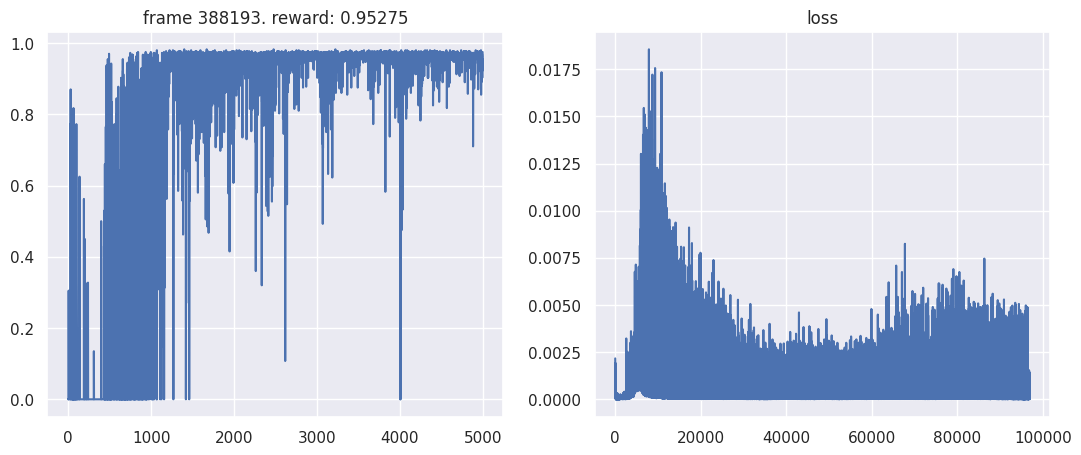

In [66]:
plot(timesteps, returns, losses)

Evaluate your model:

In [67]:
class Agent():
    def __init__(self, model, device):
        self.model = model
        self.device = device

    def select_action(self, state):
        state = np.expand_dims(state, 0)
        state = torch.tensor(state, dtype=torch.float32, device=self.device)
        with torch.no_grad():
            q_action = self.model(state).detach().cpu().numpy()

            return np.argmax(q_action)

def run_episode(env, agent, seed=None):
    state = env.reset(seed=seed)[0]
    score = 0
    done = False
    while not done:
        action = agent.select_action(state)
        state, reward, terminated, truncated, _ = env.step(action)
        score += reward
        done = terminated or truncated
    env.close()
    return score

In [68]:
N_EPISODES = 50
agent = Agent(model=dqn, device=device)

scores = []
for i in range(N_EPISODES):
    seed = np.random.randint(1e7)
    scores.append(run_episode(env, agent, seed=seed))

# Print result
print("Average Return:", np.mean(scores))

Average Return: 0.9477000000000001


In [70]:
def save_as_onnx(torch_model, sample_input, model_path):
    torch.onnx.export(torch_model,             # model being run
                    sample_input,              # model input (or a tuple for multiple inputs)
                    f=model_path,              # where to save the model (can be a file or file-like object)
                    export_params=True,        # store the trained parameter weights inside the model file
                    opset_version=17,          # the ONNX version to export the model to - see https://github.com/microsoft/onnxruntime/blob/master/docs/Versioning.md
                    do_constant_folding=True,  # whether to execute constant folding for optimization
                    external_data=False,       # keeps everything in a single .onnx file, needed if you are using torch version 2.5 or newer, comment out otherwise
                    )

In [71]:

sample_state = env.reset(seed=seed)[0]
save_as_onnx(dqn, torch.tensor(sample_state, dtype=torch.float32, device=device), 'submission_model_new.onnx')

/tmp/ipykernel_5885/1014275184.py:2: UserWarning: Exporting a model while it is in training mode. Please ensure that this is intended, as it may lead to different behavior during inference. Calling model.eval() before export is recommended.
  torch.onnx.export(torch_model,             # model being run
W0327 15:43:07.307000 5885 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0327 15:43:08.099000 5885 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float'

[torch.onnx] Obtain model graph for `MlpMinigridPolicy([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MlpMinigridPolicy([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


In [72]:
# load the onnx model and test it:
import onnx
from onnx2pytorch import ConvertModel

dqn = ConvertModel(onnx.load('submission_model_new.onnx'))
dqn = dqn.to(device)
dqn.eval()

agent = Agent(model=dqn, device=device)

scores = []
for i in range(N_EPISODES):
    seed = np.random.randint(1e7)
    scores.append(run_episode(env, agent, seed=seed))


print("Average Return:", np.mean(scores))

Average Return: 0.8523999999999999


In [73]:
from google.colab import files
files.download('submission_model_new.onnx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>